<a href="https://colab.research.google.com/github/LemdjoM/Arduino/blob/master/Assignements/Part%201/Assignment_part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSML investigation:
### You are part of the Suisse Impossible Mission Force, or SIMF for short. You need to uncover a rogue agent that is trying to steal sensitive information.

### Your mission, should you choose to accept it, is to find that agent before any classified information gets stolen. Good luck!


## Assignment part one

Airport security confiscated a laptop of a spy, which was later given to you. The laptop contains some documents that might be useful in the investigation process. You retrieve those documents and want to analyse them. Our intelligence shows that the person that we are looking for has visited the USA between Sept 2019 to Oct 2020. He is currently working undercover.


### Getting to know our data

We have retrieved from the laptop the following file:
- A list of suspects
- The flight records of these potential suspects



In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
userRecords = pd.read_csv("https://raw.githubusercontent.com/michalis0/DataScience_and_MachineLearning/refs/heads/master/Assignements/Part%201/data/userRecords.csv")
travelRecords = pd.read_csv("https://raw.githubusercontent.com/michalis0/DataScience_and_MachineLearning/refs/heads/master/Assignements/Part%201/data/flightRecords.csv")

#### Shape of the data

Let's first check how many rows and columns (features) are in the user records

In [35]:
from collections import UserString
#Your code here
userRecords.shape

(957, 8)

**Q1. How many rows are there in the user records dataset?**


#### Check out the first few rows
Print the first few rows of the user records dataset and check them. Note that to protect innocent people, the name of the suspects have been censored, those will be revealed once number of potential suspects decreases.


In [36]:
#Your code here
userRecords.head()

,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment
0,317991,Lu***,Al*****,29.07.03,AR,1,2.0,Web Designer
1,241892,Ma****,Ro*******,10.11.99,AR,1,0.0,Banker
2,303376,Fr****,Ac****,25.07.84,AR,1,0.0,Kitchen staff
3,761992,Fr****,Go***,20.03.70,AR,1,0.0,Teaching Assistant
4,373318,Jo***,Ro***,05.10.71,AR,1,0.0,Administrative employee


#### Column/feature names
print the list of columns in the user records dataset.

In [37]:
#Your code here
columns = userRecords.columns
columns

Index(['UserID', 'first_name', 'last_name', 'birthday', 'country',
       'marital_status', 'number_of_kids', 'employment'],
      dtype='object')

#### Duplicates
Check if there are any duplicate entries in the user records dataset.

__Remark__: If there are two rows in the dataset that have the same value for __all of the columns__, we consider this as a duplicate.

In [38]:
#Your code here
duplicated_rows = userRecords[userRecords.duplicated()]
duplicated_rows

,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment
19,100684,Ma*****,Me****,17.06.76,AR,NaN,0.0,Administrative employee
165,910382,Ni***,El****,21.03.75,AZ,NaN,0.0,Administrative employee
290,610518,An*****,An******,15.02.53,DK,1,NaN,Manager


Show all the duplicated rows in the user records dataset.

__Hint:__ use the method `duplicated(keep=False)` to get all occurrences of the duplicated rows.

In [39]:
#Your code here
all_duplicate_entries = userRecords[userRecords.duplicated(keep=False)]
print(all_duplicate_entries)

     UserID first_name last_name  birthday country marital_status  \
18   100684    Ma*****    Me****  17.06.76      AR            NaN   
19   100684    Ma*****    Me****  17.06.76      AR            NaN   
47   910382      Ni***    El****  21.03.75      AZ            NaN   
165  910382      Ni***    El****  21.03.75      AZ            NaN   
276  610518    An*****  An******  15.02.53      DK              1   
290  610518    An*****  An******  15.02.53      DK              1   

     number_of_kids               employment  
18              0.0  Administrative employee  
19              0.0  Administrative employee  
47              0.0  Administrative employee  
165             0.0  Administrative employee  
276             NaN                  Manager  
290             NaN                  Manager  


**Q2. Are there any duplicate entries in the user records dataset?**

*Note: Duplicate entries refer to two or more rows where all the values across every column are identical.*

**Q3. How many duplicate entries are in the user records dataset?**

(Remark: for instance: there are 2 duplicate "entries" in the following list: '1 ,2, 1, 3, 3, 4, 5'. It's 1 and 3).

Drop the duplicate entries in the user records dataset.

*   List item
*   List item



In [40]:
#Your code here
userRecords_cleaned = userRecords.drop_duplicates()
userRecords_cleaned

,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment
0,317991,Lu***,Al*****,29.07.03,AR,1,2.0,Web Designer
1,241892,Ma****,Ro*******,10.11.99,AR,1,0.0,Banker
2,303376,Fr****,Ac****,25.07.84,AR,1,0.0,Kitchen staff
3,761992,Fr****,Go***,20.03.70,AR,1,0.0,Teaching Assistant
4,373318,Jo***,Ro***,05.10.71,AR,1,0.0,Administrative employee
...,...,...,...,...,...,...,...,...
952,218415,Bu******,Mo******,22.01.01,ZA,0,1.0,Web Designer
953,173906,Th*****,Mo******,06.11.61,ZA,0,2.0,Web Designer
954,178685,Mi*****,Bu*******,29.05.53,ZA,0,1.0,Professor
955,200865,Si*******,Na****,16.12.62,ZA,0,0.0,Web Designer


### Spies often use false identities with fabricated data.

#### This suggests that if certain data points occur with statistically improbable frequency, they might be fabricated.

In this part we are going to verify if there are birthdates that have been reused an unusual amount of times.

Let's first ensure that the birthday column in the user records dataset has the correct format (datetime):


In [41]:
#Check the data type of each feature
#Your code here
userRecords_cleaned.dtypes

,0
UserID,int64
first_name,object
last_name,object
birthday,object
country,object
marital_status,object
number_of_kids,float64
employment,object


Convert the column `birthday` to datetime if necessary

*   List item
*   List item



In [42]:
#Your code here
userRecords_cleaned.loc[:, "birthday"] = pd.to_datetime(userRecords_cleaned["birthday"], dayfirst=True, errors='coerce')
userRecords_cleaned.dtypes


/tmp/ipython-input-3261515379.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  userRecords_cleaned.loc[:, "birthday"] = pd.to_datetime(userRecords_cleaned["birthday"], dayfirst=True, errors='coerce')


,0
UserID,int64
first_name,object
last_name,object
birthday,object
country,object
marital_status,object
number_of_kids,float64
employment,object


Find the list of birthdays that are duplicated/reused in the dataset

*   List item
*   List item



In [43]:
#Your code here
# count how many times birthday appear
birthday_counts = userRecords_cleaned['birthday'].value_counts()
print(birthday_counts)

# apply a filter to keep only the duplicated values
duplicated_birthdays = birthday_counts[birthday_counts > 1]

print("Anniversaires dupliqués et leur fréquence:")
print(duplicated_birthdays)

birthday
1992-06-01    4
2070-04-06    2
2054-03-26    2
1983-03-15    2
2060-06-23    2
             ..
1999-12-29    1
2072-01-14    1
1987-01-08    1
2062-11-13    1
1996-06-14    1
Name: count, Length: 929, dtype: int64
Anniversaires dupliqués et leur fréquence:
birthday
1992-06-01    4
2070-04-06    2
2054-03-26    2
1983-03-15    2
2060-06-23    2
2068-09-22    2
2057-06-25    2
2057-12-24    2
1991-12-02    2
2060-03-26    2
1999-09-12    2
1999-08-09    2
2068-10-09    2
2062-07-07    2
2055-01-08    2
2070-03-18    2
1975-01-28    2
1983-08-26    2
2067-07-24    2
1978-11-21    2
2057-12-18    2
2004-11-30    2
Name: count, dtype: int64


/tmp/ipython-input-2499041375.py:3: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  birthday_counts = userRecords_cleaned['birthday'].value_counts()


Let's count how many people have their birthday on the same day among the duplicated birthdays.

In [44]:
#Your code here
total_people = 0
for date, count in duplicated_birthdays.items():
    print(f"{date.strftime('%d.%m.%Y')}: {count} personnes")
    total_people += count
print("People having their birthday on the same day:")
print(total_people)

01.06.1992: 4 personnes
06.04.2070: 2 personnes
26.03.2054: 2 personnes
15.03.1983: 2 personnes
23.06.2060: 2 personnes
22.09.2068: 2 personnes
25.06.2057: 2 personnes
24.12.2057: 2 personnes
02.12.1991: 2 personnes
26.03.2060: 2 personnes
12.09.1999: 2 personnes
09.08.1999: 2 personnes
09.10.2068: 2 personnes
07.07.2062: 2 personnes
08.01.2055: 2 personnes
18.03.2070: 2 personnes
28.01.1975: 2 personnes
26.08.1983: 2 personnes
24.07.2067: 2 personnes
21.11.1978: 2 personnes
18.12.2057: 2 personnes
30.11.2004: 2 personnes
People having their birthday on the same day:
46


**Q4. What is the most common birthday in the dataset?**

**Q5. How many users have their birthdays on that day (the most common birthday)?**

We can consider that there is no suspicious discrepancy through birthdays.


#### We have reasons to believe that the suspect works very thoroughly, so he would make sure that the fabricated data about his identity is complete in order for his operation to run smoothly.
#### Therefore, we can exclude the people with incomplete information from the list of potential suspects.

Count how many null values are there in each column of the user records dataset. You can call `isnull()` and `sum()` to get a count of how many null values are there in each column.

In [45]:
#Your code here
userRecords_cleaned.isnull().sum()

,0
UserID,0
first_name,1
last_name,1
birthday,1
country,0
marital_status,102
number_of_kids,152
employment,1


If you encounter any null values in the dataset, be sure to exclude those entries from the suspect list.

In [46]:
#Your code here
# We first drop all the rows where at least one of the values is missing
userRecords_cleaned = userRecords_cleaned.dropna()

# Let's have another look
userRecords_cleaned.isnull().sum()

,0
UserID,0
first_name,0
last_name,0
birthday,0
country,0
marital_status,0
number_of_kids,0
employment,0


### Linking the user records to the flight records

We will now proceed to identify the users who were in the USA from Sept 1st, 2019 to Oct 31st, 2020.

We will merge the flight records with the user records in order to ensure that users who have been unsuspected in the previous step are not considered.

In [47]:
#check the user records dataset
print("Dimensions:", userRecords_cleaned.shape)
print("Data types:", userRecords_cleaned.dtypes)
print("Missing Values :", userRecords_cleaned.isnull().sum())

print("Available Columnns :", list(userRecords_cleaned.columns))
print("Unic Identifiers:", userRecords_cleaned['UserID'].nunique())


Dimensions: (714, 8)
Data types: UserID              int64
first_name         object
last_name          object
birthday           object
country            object
marital_status     object
number_of_kids    float64
employment         object
dtype: object
Missing Values : UserID            0
first_name        0
last_name         0
birthday          0
country           0
marital_status    0
number_of_kids    0
employment        0
dtype: int64
Available Columnns : ['UserID', 'first_name', 'last_name', 'birthday', 'country', 'marital_status', 'number_of_kids', 'employment']
Unic Identifiers: 714


In [48]:
#check the flight records dataset
print("Dimensions:", travelRecords.shape)
print("Data types:", travelRecords.dtypes)
print("Missing Values:", travelRecords.isnull().sum())
print("Available Columnns :", list(travelRecords.columns))
print("Unic Identifiers:", travelRecords['flightName'].nunique())



Dimensions: (25399, 5)
Data types: flightName     object
departure      object
destination    object
date           object
userID          int64
dtype: object
Missing Values: flightName     0
departure      0
destination    0
date           0
userID         0
dtype: int64
Available Columnns : ['flightName', 'departure', 'destination', 'date', 'userID']
Unic Identifiers: 25393


[Merging](https://pandas.pydata.org/docs/user_guide/merging.html) the two datasets:

*Hint: Use the above questions to identify on what feature to merge the datasets*

The result should contain the features flightName, Departure, Arrival,  Date, UserID, first_name, last_name, etc.

In [49]:
#Your code here
merged_data = userRecords_cleaned.merge(
    travelRecords,
    left_on='UserID',           # users' columns
    right_on='userID',     # travel's columns
    how='inner'
)

print(f"✅ Merged Dataset: {merged_data.shape[0]} lines x {merged_data.shape[1]} columns")


✅ Merged Dataset: 19037 lines x 13 columns


Remember, our suspect operates meticulously, ensuring that there are no null values in any entries.

In [59]:
#Your code here
merged_data_cleaned = merged_data.dropna(how='any') # 'any' means drop a row if ANY column is null
merged_data_cleaned.shape

(19037, 13)

Let's now identify the users who has **travelled to** the United States (US) between the 1st of september 2019 and the 31st of october 2020.

*Note that the travel date is not in datetime format.*

In [91]:
#Your code here
# 2. Convert date column and filter for USA travels in the specified period
# (We will also need to identify the correct date and destination column names)
merged_data_cleaned['date'] = pd.to_datetime(merged_data_cleaned['date'])
usa_travelers = merged_data_cleaned[
    (merged_data_cleaned['date'] >= '2019-09-01') &
    (merged_data_cleaned['date'] <= '2020-10-31') &
    (merged_data_cleaned['destination'].str.contains('USA|United States|US', case=False, na=False))
    ]

usa_travelers_cleaned = usa_travelers.dropna(how='any') # 'any' means drop a row if ANY column is null
print(f"users who has travelled to the United States (US) between the 1st of september 2019 and the 31st of october 2020: {len(usa_travelers_cleaned)}")

print("\nSuspect User IDs:", usa_travelers_cleaned['UserID'].unique()) # <-- Use the actual ID column name

users who has travelled to the United States (US) between the 1st of september 2019 and the 31st of october 2020: 38

Suspect User IDs: [468560 255830 861915 220420 297653 206269 512432 710764 267733 429697
 412064 649131 481578 434361 804662 287607 411537 424791 679196 410319
 556033 139646 628854 762279 638911 785994 642133 428951 739104 852352
 123699 581969 409055 850103 707686 942571 539529 866017]


**Q6. How many suspects travelled to the US between the 1st of September 2019 and the 31st of October 2020?**

**Q7. Which users are included in the remaining list of suspects who traveled to the US between the 1st of September 2019 and the 31st of October 2020?** Choose from the answers on Moodle.

## [Data visualisation ](https://pandas.pydata.org/docs/user_guide/visualization.html)

 Suisse Impossible Mission Force is happy with the result and would like to have some visual aid to make a profile of the potential suspects.

Let's create a pie chart to visualize the employment distribution among the suspects who traveled to US between September 1st, 2019, and October 31st, 2020.


📊 PROFESSIONAL DISTRIBUTION OF THE 38 SUSPECTS:


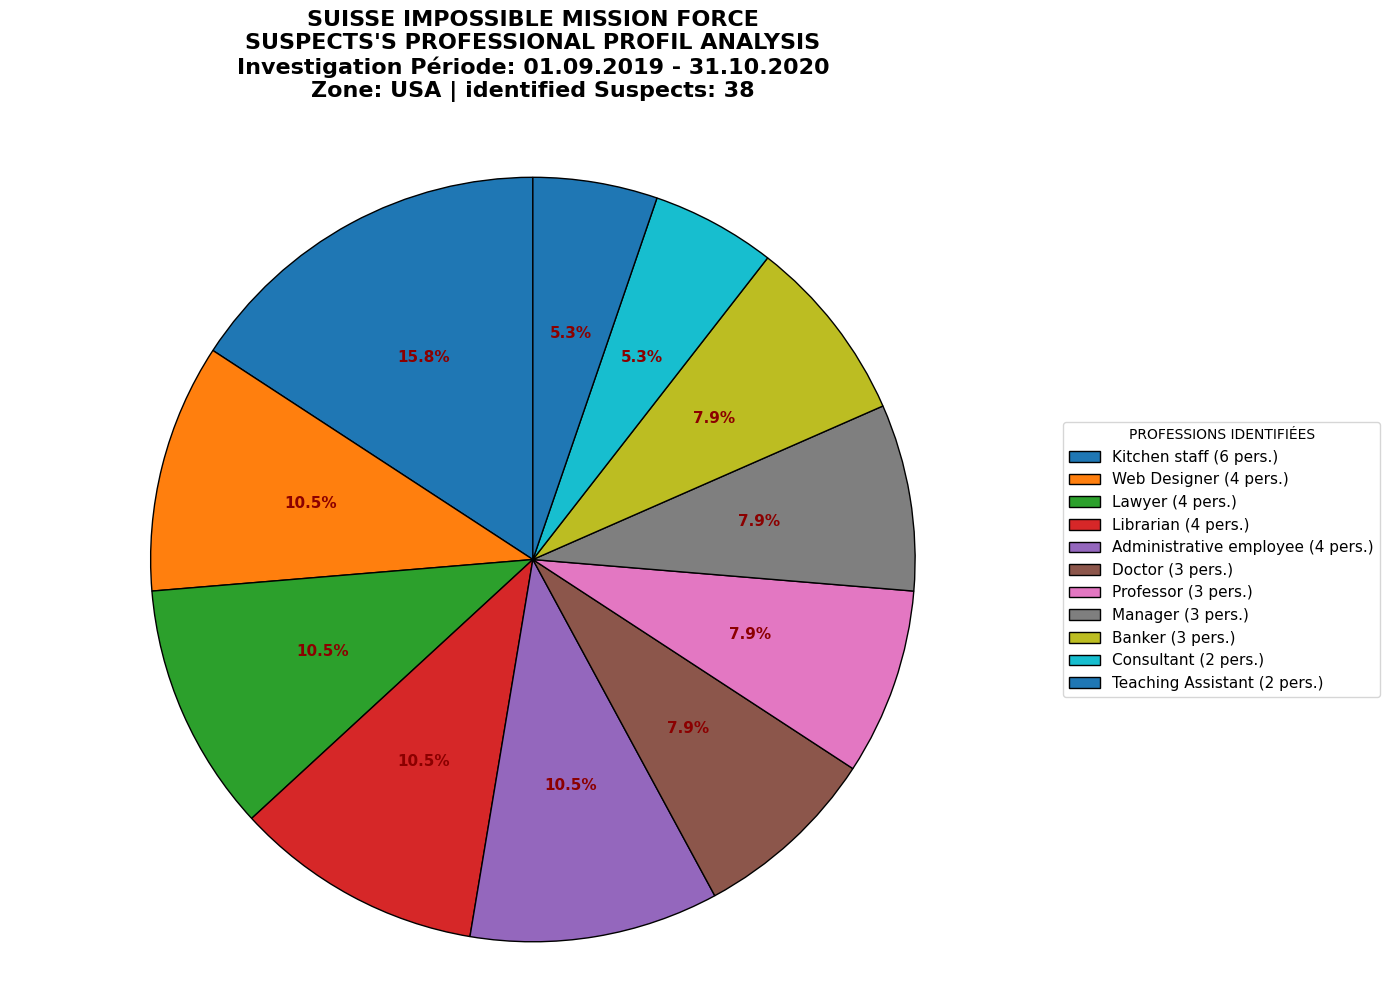

In [88]:
#Your code here
import seaborn as sns

# Count the distribution of the professions
employment_distribution = usa_travelers_cleaned['employment'].value_counts()

print(f"\n📊 PROFESSIONAL DISTRIBUTION OF THE {len(usa_travelers_cleaned)} SUSPECTS:")
print("=" * 50)

total_suspects = len(usa_travelers_cleaned)
for profession, count in employment_distribution.items():
    percentage = (count / total_suspects) * 100


# Creation of the diagram
plt.figure(figsize=(14, 10))

plt.pie(
    employment_distribution.values,
    labels=None,  # Pas de labels directs
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("tab10", len(employment_distribution)),
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},
    textprops={'fontsize': 11, 'fontweight': 'bold', 'color': 'darkred'}
)

plt.title(
    'SUISSE IMPOSSIBLE MISSION FORCE\n'
    'SUSPECTS\'S PROFESSIONAL PROFIL ANALYSIS\n'
    f'Investigation Période: 01.09.2019 - 31.10.2020\n'
    f'Zone: USA | identified Suspects: {total_suspects}',
    fontsize=16,
    fontweight='bold',
    pad=30
)

# Legende
legend_labels = [f'{prof} ({count} pers.)' for prof, count in
                zip(employment_distribution.index, employment_distribution.values)]
plt.legend(
    #wedges,
    legend_labels,
    title="PROFESSIONS IDENTIFIÉES",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.axis('equal')

plt.tight_layout()
plt.show()

**Q8. Which profession is the least represented among the suspects the suspects who traveled to US between September 1st, 2019, and October 31st, 2020?**
 Choose from the answers on Moodle.


## Journey length

The Suisse Impossible Mission Force suspects that the rogue agent is an anomaly within his declared employment category, particularly in terms of the number of days he spent at destinations compared to his peers.

To identify such deviations, we can employ boxplots for each employment category, allowing us to visually identify outliers in the data.

First, let's construct two tables: one for the dates of arrival and another for the dates of departure. Utilize the existing dataset to extract these dates based on the 'destination' and 'departure' columns. Ensure that both the arrival and departure dates are within the period the suspect is believed to have been in the US, which is from September 2019 to October 2020.

In [95]:
# For this step we will need the information not only about the fights to the US,
# but also about the flights taken from the US
# Your code here
user_to_usa = merged_data_cleaned[
    (merged_data_cleaned['date'] >= '2019-09-01') &
    (merged_data_cleaned['date'] <= '2020-10-31') &
    (merged_data_cleaned['destination'].str.contains('USA|United States|US', case=False, na=False)) ]

users_from_usa = merged_data_cleaned[
    (merged_data_cleaned['date'] >= '2019-09-01') &
    (merged_data_cleaned['date'] <= '2020-10-31') &
    (merged_data_cleaned['departure'].str.contains('USA|United States|US', case=False, na=False)) ]



We can keep on both of these tables the user ID, employment, and departure date / arrival date.

In [54]:
#Your code here


We can now join the two tables on user ID.

In [55]:
#Your code here

We can now create a new feature called journey_length representing the difference between departure date and arrival date.

*Hint: Ensure that the journey_length is in the right format*

In [56]:
#Your code here


*Sidenote: if you get negative journey length, what would be your explanation to that?*

We can now create the boxplots where the x-axis represents each profession and the y-axis corresponds to the journey length.

In [57]:
#Your code here


**Q9. Which profession has the most staggering outlier?**
(Meaning that the outlier value is the farthest away from the corresponding boxplot.)

### SIMF is satisfied with your work but believes the current data is inconclusive.

Your investigation will continue when more intelligence comes in...

**Don't forget to complete the moodle quiz ([Assignment Q1](https://moodle.unil.ch/mod/quiz/view.php?id=1744562)) and submit your code ([Code Q1](https://moodle.unil.ch/mod/assign/view.php?id=1744563)) on Moodle before Monday 30.09.2024.**